# **Pre-processing**

In [ ]:
# Use this cell to connect to your Google Drive
# allow all permissions
# should output "Mounted at /content/drive"
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

!pwd
!ls /content/drive

# this should output:
# /content
# MyDrive  Shareddrives

/content
MyDrive  Shareddrives


In [ ]:
!ls /content/drive/MyDrive/ufo.csv
# should output "/content/drive/MyDrive/ufo.csv"

/content/drive/MyDrive/ufo.csv


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/ufo.csv')
df.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


In [ ]:
#convert latitude and duration to numeric values
df = df[df.latitude.str.contains(r'^[0-9.]+$', na=False)]
df['latitude'] = df['latitude'].astype(float)

In [ ]:
#filtering out incorrect datetimes
indices_to_drop = df[df['datetime'].str.contains(r'( 24:)')].index
df.drop(indices_to_drop, inplace=True)
df['datetime'] = pd.to_datetime(df['datetime'])

df.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.883056,-97.941111
1,1949-10-10 21:00:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.384210,-98.581082
2,1955-10-10 17:00:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.200000,-2.916667
3,1956-10-10 21:00:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.978333,-96.645833
4,1960-10-10 20:00:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.418056,-157.803611


In [ ]:
#dropping unnecessary/duplicate features
df = df.drop('duration (hours/min)', axis=1)
df = df.drop('date posted', axis=1)
df.head()

,datetime,city,state,country,shape,duration (seconds),comments,latitude,longitude
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,This event took place in early fall around 194...,29.883056,-97.941111
1,1949-10-10 21:00:00,lackland afb,tx,NaN,light,7200,1949 Lackland AFB&#44 TX. Lights racing acros...,29.384210,-98.581082
2,1955-10-10 17:00:00,chester (uk/england),NaN,gb,circle,20,Green/Orange circular disc over Chester&#44 En...,53.200000,-2.916667
3,1956-10-10 21:00:00,edna,tx,us,circle,20,My older brother and twin sister were leaving ...,28.978333,-96.645833
4,1960-10-10 20:00:00,kaneohe,hi,us,light,900,AS a Marine 1st Lt. flying an FJ4B fighter/att...,21.418056,-157.803611


In [ ]:
#data is exclusively USA now
df = df[df['country'] == 'us']

#making data exclusively continental US, so dropping alaska, hawaii, and puerto rico
df = df[(df['state'] != 'ak') & (df['state'] != 'hi') & (df['state'] != 'pr')]

In [ ]:
#uniform columns
df.columns = df.columns.str.strip().str.lower()

In [ ]:
#calculate range of longitude coordinates
max_longitude = -66.949778
min_longitude = -124.771694
longitude_range = max_longitude - min_longitude

#calculating range of latitude coordinates
max_latitude = 49.384467
min_latitude = 24.446667
latitude_range = max_latitude - min_latitude

#put instances into a tuple grid
df['lat_bin'] = pd.cut(df['latitude'], bins=10, labels=False)
df['long_bin'] = pd.cut(df['longitude'], bins=10, labels=False)
df['grid'] = list(zip(df['lat_bin'], df['long_bin']))

df.head()

,datetime,city,state,country,shape,duration (seconds),comments,latitude,longitude,lat_bin,long_bin,grid
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,This event took place in early fall around 194...,29.883056,-97.941111,2,4,"(2, 4)"
3,1956-10-10 21:00:00,edna,tx,us,circle,20,My older brother and twin sister were leaving ...,28.978333,-96.645833,1,4,"(1, 4)"
5,1961-10-10 19:00:00,bristol,tn,us,sphere,300,My father is now 89 my brother 52 the girl wit...,36.595000,-82.188889,4,7,"(4, 7)"
7,1965-10-10 23:45:00,norwalk,ct,us,disk,1200,A bright orange color changing to reddish colo...,41.117500,-73.408333,6,8,"(6, 8)"
8,1966-10-10 20:00:00,pell city,al,us,disk,180,Strobe Lighted disk shape object observed clos...,33.586111,-86.286111,3,6,"(3, 6)"


In [ ]:
#converting tuples to ordinal numbers
tuples = sorted(df['grid'].unique())

tuple_to_index = {t: i for i, t in enumerate(tuples)}
df['grid_id'] = df['grid'].map(tuple_to_index)

#drop old grid columns
df = df.drop('lat_bin', axis=1)
df = df.drop('long_bin', axis=1)
df = df.drop('grid', axis=1)

In [ ]:
#sorts by latitude basically so check that texas, the southernmost, is in the first few rows and maine is in the last few
df.sort_values(by='grid_id')

,datetime,city,state,country,shape,duration (seconds),comments,latitude,longitude,grid_id
15504,2014-01-16 18:15:00,mcallen,tx,us,teardrop,300,My mother and I were traveling South on Biccen...,26.203056,-98.229722,0
9639,2012-11-15 05:15:00,brownsville,tx,us,oval,120,Oval shape light&#44gliding within some clouds...,25.901389,-97.497222,0
44545,2013-05-26 23:25:00,sullivan city,tx,us,triangle,300,Triangle object flying over my house in South ...,26.277222,-98.563333,0
7705,2005-11-10 01:05:00,port isabel,tx,us,disk,360,Large disc shaped object with red lights on so...,26.073056,-97.208333,0
5198,2013-10-28 20:20:00,brownsville,tx,us,circle,90,2 orange fiery&#44 round objects flew over bro...,25.901389,-97.497222,0
...,...,...,...,...,...,...,...,...,...,...
52056,1999-06-27 23:42:00,ashland,me,us,triangle,120,I was standing outside when I saw a light in t...,46.631111,-68.406667,77
23580,2008-01-28 00:00:00,presque isle,me,us,fireball,120,Huge fireball emitting a white light that lit ...,46.681111,-68.016389,77
40829,2004-04-08 06:00:00,maine (location unspecified),me,us,unknown,180,A dream where I traveled out of my body into s...,46.820000,-67.923611,77
33073,2012-03-22 01:00:00,presque isle,me,us,triangle,120,Two amber colored objects appeared to be playi...,46.681111,-68.016389,77


In [ ]:
import re

#clean comment text
df['comments'] = (df['comments'].astype(str).str.lower().str
                 .replace(r'[^a-z\s]', '', regex=True).str.strip())

#list of possible colors
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple', 'pink',
          'white', 'grey', 'gray', 'black', 'silver', 'gold', 'brown', 'amber',
          'bright']

#making encoded columns for each color
for color in colors:
  df[color] = df['comments'].str.contains(color).astype(int)


#list of possible sizes
sizes = ["small", "medium", "large", "huge", "tiny", "massive"]

#making encoded columns for each color
for size in sizes:
  df[size] = df['comments'].str.contains(size).astype(int)


#list of possible behaviors
behaviors = ["hovering", "moving", "zigzag", "fast", "slow", "stationary"]

#making encoded columns for each behaviors
for behavior in behaviors:
  df[behavior] = df['comments'].str.contains(behavior).astype(int)


#list of possible directions
directions = ["north", "south", "east", "west", "up", "down"]

#making encoded columns for each directions
for direction in directions:
  df[direction] = df['comments'].str.contains(direction).astype(int)


#list of possible weather
weather = ["cloudy", "clear", "rain", "storm", "fog"]

#making encoded columns for each weather
for weather_type in weather:
  df[weather_type] = df['comments'].str.contains(weather_type).astype(int)

In [ ]:
df.drop(columns=df.columns[(df == 0).all()], inplace=True)

df['duration (seconds)'] = pd.to_numeric(df['duration (seconds)'], errors='coerce')
df = df.dropna(subset=['duration (seconds)'])
df['duration (seconds)'] = df['duration (seconds)'].astype(float)

# **Neural nets**

In [ ]:
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, ParameterGrid

import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [ ]:
#getting numerics
df_copy = df.copy()
df_cleaned = df_copy.dropna()

df_less_features = df_cleaned.drop(['city', 'country', 'comments', 'latitude',
                                    'longitude', 'state'], axis=1)
df_dummied = pd.get_dummies(df_less_features)

#extracting X and y
y = df_dummied['grid_id']
X = df_dummied.drop('grid_id', axis=1)

#turning datetime into other features, scikit doesn't like them
X['year'] = X['datetime'].dt.year
X['month'] = X['datetime'].dt.month
X['day'] = X['datetime'].dt.day
X['hour'] = X['datetime'].dt.hour

#dropping OG datetime column
X = X.drop(columns=['datetime'])

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)

nn = MLPClassifier(hidden_layer_sizes=(50,),
                   activation='tanh',
                   solver='adam',
                   max_iter=500,
                   random_state=42)

nn.fit(X_train, y_train)

y_predicted = nn.predict(X_train)
accuracy = accuracy_score(y_train, y_predicted)
accuracy

0.0980526638089406

In [ ]:
y_test_predicted = nn.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_predicted)
test_accuracy

0.07681003233075341

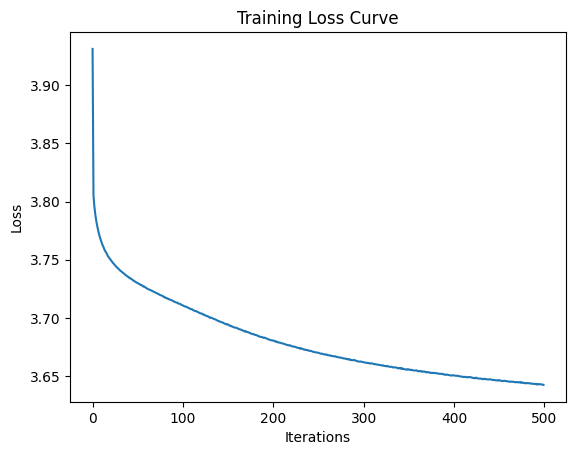

In [ ]:
import matplotlib.pyplot as plt

plt.plot(nn.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()


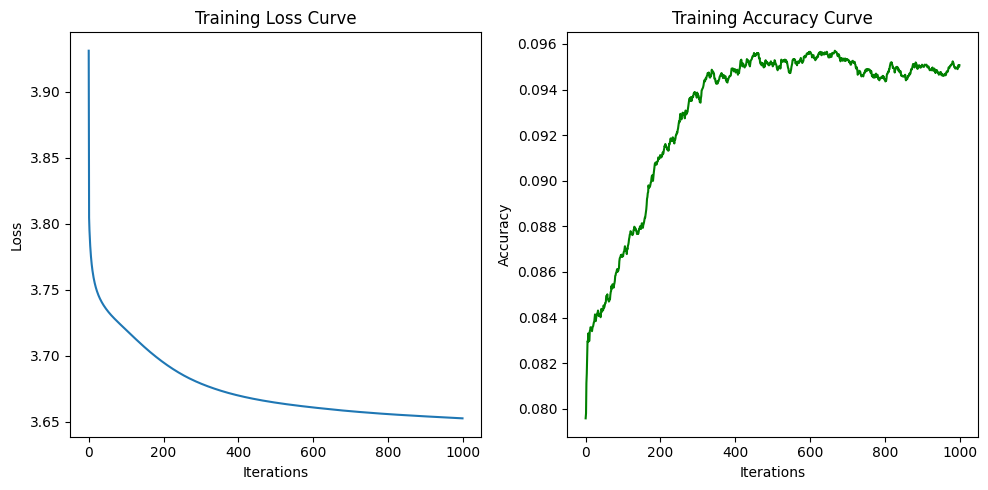

In [ ]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

#create the same model but with warm_start
nn = MLPClassifier(hidden_layer_sizes=(50,),
                   activation='tanh',
                   solver='adam',
                   max_iter=1,
                   warm_start=True,
                   random_state=42)

train_acc = []
losses = []

#training for 1000 iterations
for i in range(1000):
    nn.fit(X_train, y_train_encoded)
    y_pred = nn.predict(X_train)
    acc = accuracy_score(y_train_encoded, y_pred)
    train_acc.append(acc)
    losses.append(nn.loss_)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(losses, label="Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.subplot(1, 2, 2)
plt.plot(train_acc, label="Accuracy", color='green')
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Curve")

plt.tight_layout()
plt.show()